In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import t
from scipy.stats import genextreme
from scipy.stats import chi2


#1. Data Collection

Given the re-election of president Trump in Nov 2024, certain sectors are poised to experience notable shifts due to anticipated policy changes. I believe focusing on these sectors can provide valuable insights into tail risk dynamics in the current political and economic landscape.

Some of the sectors we are going to use"

* Energy: Trump's administration is expected to favor fossil fuel industries, potentially leading to deregulation and increased exploration activities. This could result in heightened volatility within the energy sector.
* Finance: anticipated deregularization under the current administration may encourage mergers and acquisitions, impacting the financial sector's stability and risk profile.
* Utilities: an increased focus on energy production and infrastructure development could influence ultility companies, affecting their market performance and associated risks.


In [3]:
tickers = ['SPY', 'XLE', 'XOM', 'XLF', 'JPM', 'LMT', 'NEE']
start_date = '2010-01-01'
end_date = '2025-04-01'

data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Calculate daily returns
returns = data.pct_change().dropna()

# Preview the dataset
print("Daily Returns:")
print(returns.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  7 of 7 completed

Daily Returns:
Ticker           JPM       LMT       NEE       SPY       XLE       XLF  \
Date                                                                     
2010-01-05  0.019369  0.010410 -0.009766  0.002647  0.008162  0.018380   
2010-01-06  0.005495 -0.014681  0.009862  0.000704  0.011975  0.002005   
2010-01-07  0.019809 -0.027447 -0.002817  0.004221 -0.001500  0.021348   
2010-01-08 -0.002456  0.016127 -0.008663  0.003328  0.006510 -0.005878   
2010-01-11 -0.003357  0.004761 -0.000760  0.001397 -0.001327  0.000657   

Ticker           XOM  
Date                  
2010-01-05  0.003905  
2010-01-06  0.008643  
2010-01-07 -0.003142  
2010-01-08 -0.004011  
2010-01-11  0.011220  


In [4]:
returns

Ticker,JPM,LMT,NEE,SPY,XLE,XLF,XOM
Date,,,,,,,
2010-01-05,0.019369,0.010410,-0.009766,0.002647,0.008162,0.018380,0.003905
2010-01-06,0.005495,-0.014681,0.009862,0.000704,0.011975,0.002005,0.008643
2010-01-07,0.019809,-0.027447,-0.002817,0.004221,-0.001500,0.021348,-0.003142
2010-01-08,-0.002456,0.016127,-0.008663,0.003328,0.006510,-0.005878,-0.004011
2010-01-11,-0.003357,0.004761,-0.000760,0.001397,-0.001327,0.000657,0.011220
...,...,...,...,...,...,...,...
2025-03-25,0.012376,0.016300,-0.021122,0.002404,0.004093,0.005583,0.006822
2025-03-26,-0.000398,0.007012,0.016621,-0.011938,0.005899,-0.002974,0.014409
2025-03-27,-0.011592,-0.006492,0.004302,-0.002656,-0.009704,-0.001989,-0.003213


In [5]:
returns.describe()

Ticker,JPM,LMT,NEE,SPY,XLE,XLF,XOM
count,3833.000000,3833.000000,3833.000000,3833.000000,3833.000000,3833.000000,3833.000000
mean,0.000709,0.000671,0.000649,0.000547,0.000401,0.000541,0.000415
std,0.017461,0.013260,0.013909,0.010734,0.017223,0.013904,0.015696
min,-0.149649,-0.127616,-0.134170,-0.109424,-0.201412,-0.137093,-0.122248
25%,-0.007625,-0.005556,-0.006110,-0.003724,-0.007665,-0.005824,-0.007184
50%,0.000617,0.000790,0.001064,0.000682,0.000547,0.000763,0.000165
75%,0.009112,0.007280,0.007542,0.005790,0.008730,0.007443,0.008029
max,0.180125,0.107279,0.136904,0.090604,0.160373,0.131566,0.126868


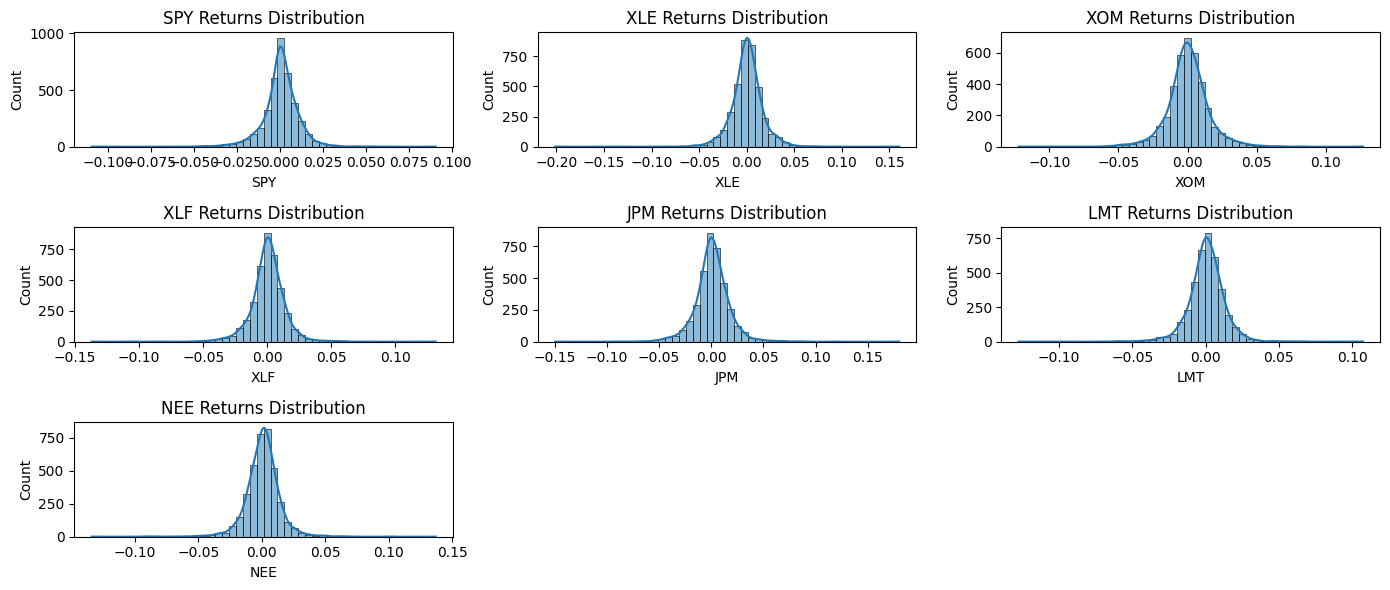

In [6]:
plt.figure(figsize=(14, 6))
for i, ticker in enumerate(tickers):
    plt.subplot(3, 3, i+1)
    sns.histplot(returns[ticker], kde=True, bins=50)
    plt.title(f'{ticker} Returns Distribution')
plt.tight_layout()
plt.show()


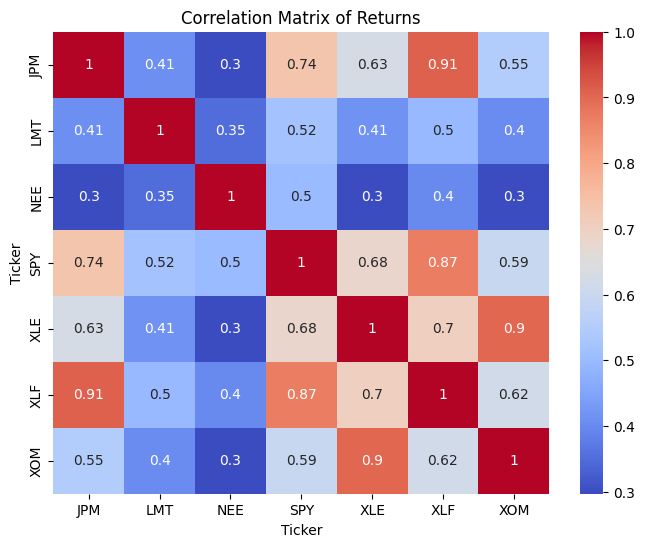

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Returns")
plt.show()


* All stocks have small positive mean returns, which is typical, but the signal-to-noise-ratio is low. This means the returns are volatile

In [8]:
print("Summary Statistics for Returns:", returns.describe())

Summary Statistics for Returns: Ticker          JPM          LMT          NEE          SPY          XLE  \
count   3833.000000  3833.000000  3833.000000  3833.000000  3833.000000   
mean       0.000709     0.000671     0.000649     0.000547     0.000401   
std        0.017461     0.013260     0.013909     0.010734     0.017223   
min       -0.149649    -0.127616    -0.134170    -0.109424    -0.201412   
25%       -0.007625    -0.005556    -0.006110    -0.003724    -0.007665   
50%        0.000617     0.000790     0.001064     0.000682     0.000547   
75%        0.009112     0.007280     0.007542     0.005790     0.008730   
max        0.180125     0.107279     0.136904     0.090604     0.160373   

Ticker          XLF          XOM  
count   3833.000000  3833.000000  
mean       0.000541     0.000415  
std        0.013904     0.015696  
min       -0.137093    -0.122248  
25%       -0.005824    -0.007184  
50%        0.000763     0.000165  
75%        0.007443     0.008029  
max        0

For skewness:
* Negative skew means long left tail, while positive skew means long right tail (rare big gains)

In [9]:
print("\nSkewness:")
print(returns.skew())


Skewness:
Ticker
JPM    0.219887
LMT   -0.378935
NEE   -0.193965
SPY   -0.510926
XLE   -0.386674
XLF   -0.226197
XOM    0.049870
dtype: float64


In [10]:
print("\nKurtosis:")
print(returns.kurtosis())


Kurtosis:
Ticker
JPM     9.855102
LMT    12.787643
NEE    10.639892
SPY    10.640336
XLE    12.996623
XLF    11.359939
XOM     7.135372
dtype: float64


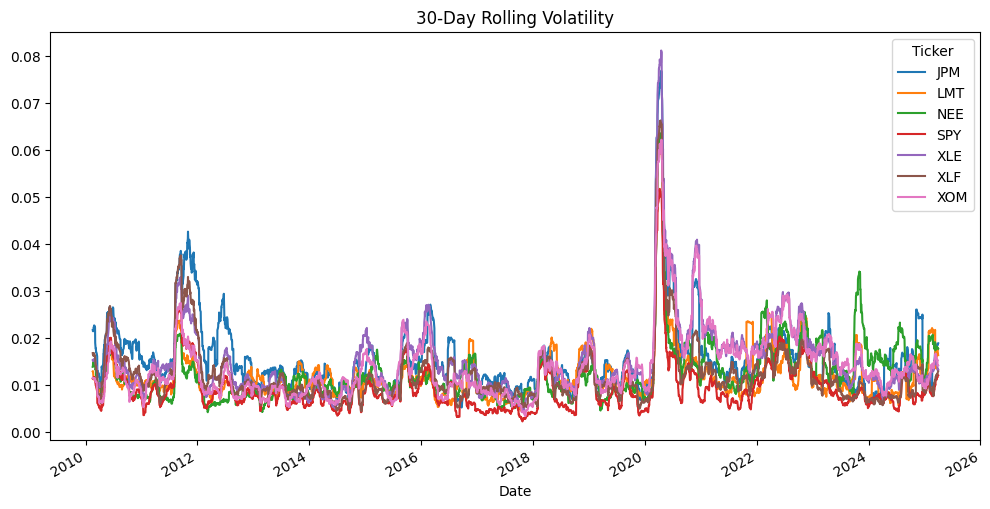

In [11]:
# Rolling volatility
returns.rolling(30).std().plot(figsize=(12,6), title='30-Day Rolling Volatility')
plt.show()

* Tail events are not rare enough for normal assumptions --> we should estimate VaR and Expected Shortfall
* Use fat-tailed models to do so (like t-distribution, GPD, or EVT)

In [12]:
#tail event count
extreme_events = (np.abs(returns) > 3 * returns.std()).sum()
print("Extreme events (> 3σ):\n", extreme_events)


Extreme events (> 3σ):
 Ticker
JPM    55
LMT    52
NEE    61
SPY    56
XLE    46
XLF    60
XOM    56
dtype: int64


#3. Estimate VaR and ES

* In this stpe, we re trying to quantify potential losses under extreme market conditions, which is essential in tail risk study

### Historical VaR/ ES

In [13]:
confidence_level = 0.95
quantile = 1 - confidence_level

historical_var = returns.quantile(quantile)
historical_es = returns[returns.lt(historical_var)].mean()

print("Historical VaR (95%):\n", historical_var)
print("\nHistorical ES (95%):\n", historical_es)


Historical VaR (95%):
 Ticker
JPM   -0.025806
LMT   -0.018389
NEE   -0.019772
SPY   -0.016547
XLE   -0.025776
XLF   -0.021066
XOM   -0.022946
Name: 0.050000000000000044, dtype: float64

Historical ES (95%):
 Ticker
JPM   -0.039639
LMT   -0.030560
NEE   -0.032144
SPY   -0.026107
XLE   -0.039384
XLF   -0.032586
XOM   -0.035900
dtype: float64


### Parametric VaR & ES (Normal)

In [14]:
z_score = norm.ppf(quantile)
normal_var = returns.mean() + z_score * returns.std()
normal_es = returns.mean() - returns.std() * norm.pdf(z_score) / quantile

print("Parametric VaR (Normal):\n", normal_var)
print("\nParametric ES (Normal):\n", normal_es)


Parametric VaR (Normal):
 Ticker
JPM   -0.028011
LMT   -0.021139
NEE   -0.022229
SPY   -0.017109
XLE   -0.027928
XLF   -0.022329
XOM   -0.025403
dtype: float64

Parametric ES (Normal):
 Ticker
JPM   -0.035308
LMT   -0.026680
NEE   -0.028041
SPY   -0.021594
XLE   -0.035125
XLF   -0.028139
XOM   -0.031962
dtype: float64


### Parametric VaR & ES (Student-t)

In [15]:
t_var = {}
t_es = {}

for ticker in tickers:
    r = returns[ticker].dropna()
    df, loc, scale = t.fit(r)
    t_quantile = t.ppf(quantile, df, loc=loc, scale=scale)
    t_var[ticker] = t_quantile
    # Expected Shortfall formula for t-distribution
    t_es[ticker] = -t.pdf(t.ppf(quantile, df), df) * (df + t.ppf(quantile, df)**2) / ((df - 1) * quantile) * scale + loc

print("Parametric VaR (Student-t):\n", pd.Series(t_var))
print("\nParametric ES (Student-t):\n", pd.Series(t_es))


Parametric VaR (Student-t):
 SPY   -0.016769
XLE   -0.024775
XOM   -0.023073
XLF   -0.019380
JPM   -0.024848
LMT   -0.018141
NEE   -0.019332
dtype: float64

Parametric ES (Student-t):
 SPY   -0.036993
XLE   -0.039482
XOM   -0.037173
XLF   -0.031960
JPM   -0.040512
LMT   -0.029287
NEE   -0.031325
dtype: float64


* Based on the summary, we know that:
  * Student-t is more conservative
  * Normal distribution often underestimate ES
  * NEE and BAC seem to have the most extreme potential losses under multiple methods.

In [16]:
ans = pd.DataFrame({
    'Hist_VaR': historical_var,
    'Hist_ES': historical_es,
    'Norm_VaR': normal_var,
    'Norm_ES': normal_es,
    'T_VaR': pd.Series(t_var),
    'T_ES': pd.Series(t_es)
})
print(ans)


     Hist_VaR   Hist_ES  Norm_VaR   Norm_ES     T_VaR      T_ES
JPM -0.025806 -0.039639 -0.028011 -0.035308 -0.024848 -0.040512
LMT -0.018389 -0.030560 -0.021139 -0.026680 -0.018141 -0.029287
NEE -0.019772 -0.032144 -0.022229 -0.028041 -0.019332 -0.031325
SPY -0.016547 -0.026107 -0.017109 -0.021594 -0.016769 -0.036993
XLE -0.025776 -0.039384 -0.027928 -0.035125 -0.024775 -0.039482
XLF -0.021066 -0.032586 -0.022329 -0.028139 -0.019380 -0.031960
XOM -0.022946 -0.035900 -0.025403 -0.031962 -0.023073 -0.037173


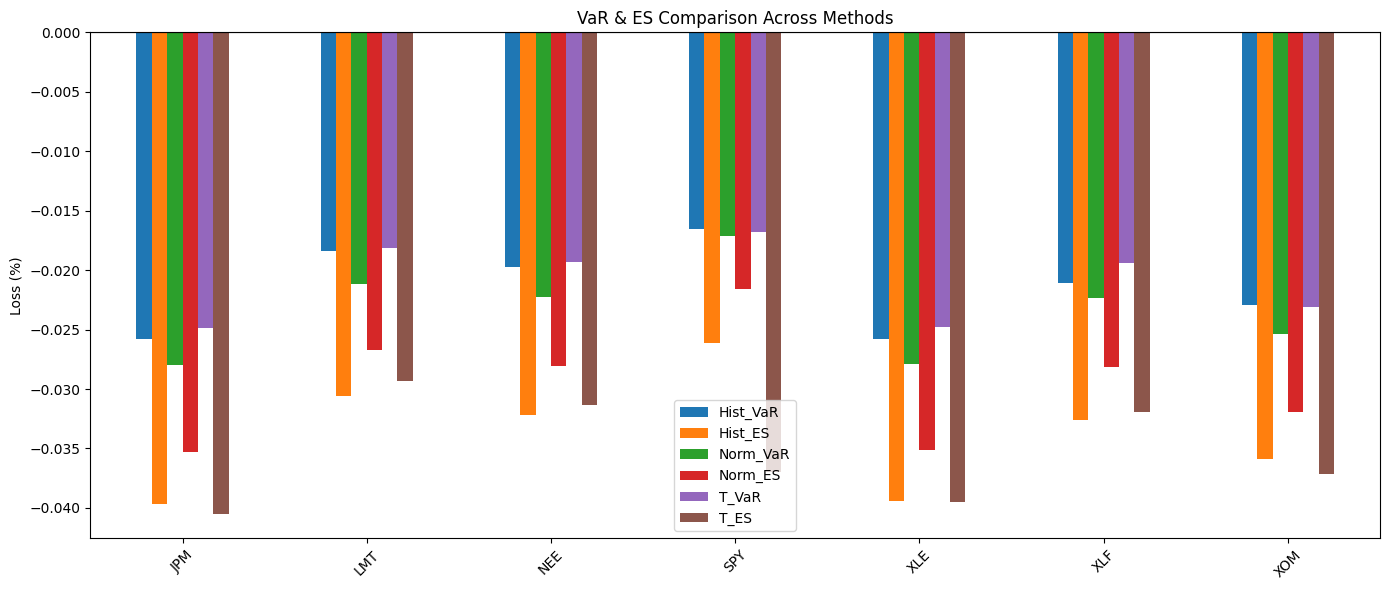

In [17]:
ans.plot(kind='bar', figsize=(14, 6), title="VaR & ES Comparison Across Methods")
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Loss (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Advanced Tail Risk Modeling

In [18]:
# Compute 30-day and 60-day rolling max drawdowns
drawdown_30 = data / data.rolling(window=30).max() - 1
drawdown_60 = data / data.rolling(window=60).max() - 1

# Hybrid: from all-time high (cumulative max)
drawdown_peak = data / data.cummax() - 1

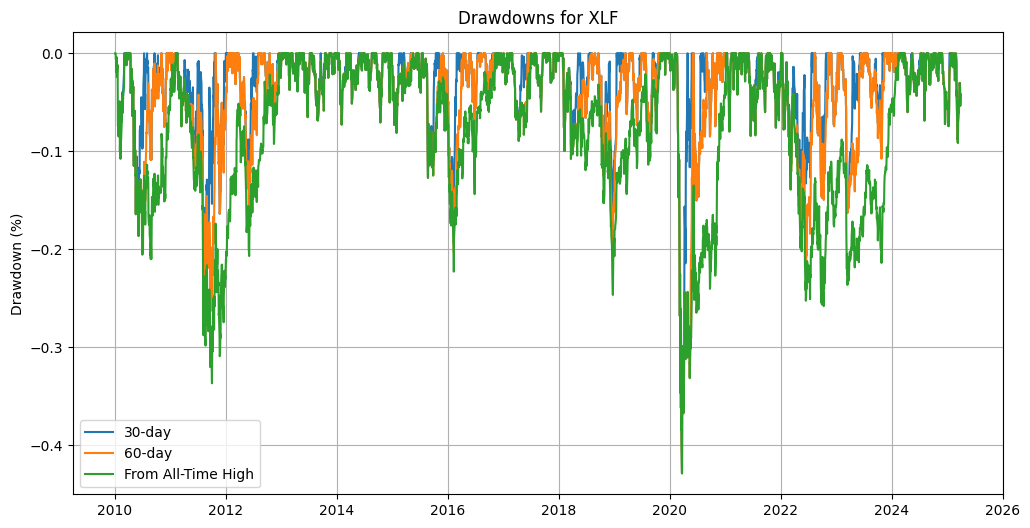

In [19]:
# Select 1 asset for demonstration (e.g., XLF)
asset = 'XLF'
# Plot drawdown paths
plt.figure(figsize=(12, 6))
plt.plot(drawdown_30[asset], label='30-day')
plt.plot(drawdown_60[asset], label='60-day')
plt.plot(drawdown_peak[asset], label='From All-Time High')
plt.title(f'Drawdowns for {asset}')
plt.ylabel("Drawdown (%)")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# Step 3: Extract lowest X% drawdowns and fit GEV

def fit_gev(drawdowns, asset, tail_frac=0.01):
    data = drawdowns[asset].dropna()
    n_tail = int(len(data) * tail_frac)
    tail_losses = data.nsmallest(n_tail)  # Largest negative drawdowns
    c, loc, scale = genextreme.fit(-tail_losses)  # Use negative values
    return {'alpha': -c, 'scale': scale, 'loc': loc}

# Fit for each drawdown type
results = {
    '30-day': fit_gev(drawdown_30, asset),
    '60-day': fit_gev(drawdown_60, asset),
    'All-Time High': fit_gev(drawdown_peak, asset)
}


In [21]:
print(f"GEV Estimates for {asset}:\n")
for key, val in results.items():
    print(f"{key} drawdowns:")
    print(f"  Tail Index (alpha): {val['alpha']:.4f}")
    print(f"  Scale (σ): {val['scale']:.4f}")
    print(f"  Location: {val['loc']:.4f}\n")

GEV Estimates for XLF:

30-day drawdowns:
  Tail Index (alpha): 0.0871
  Scale (σ): 0.0580
  Location: 0.2321

60-day drawdowns:
  Tail Index (alpha): 0.2001
  Scale (σ): 0.0223
  Location: 0.3064

All-Time High drawdowns:
  Tail Index (alpha): 0.5831
  Scale (σ): 0.0130
  Location: 0.3117



In [22]:
# Apply GEV fitting across all assets for each drawdown type
summary = []

for ticker in tickers:
    row = {'Asset': ticker}
    row.update({f'{label}_alpha': fit_gev(drawdown, ticker)['alpha']
                for label, drawdown in zip(['30', '60', 'Peak'],
                                           [drawdown_30, drawdown_60, drawdown_peak])})
    summary.append(row)

gev_summary = pd.DataFrame(summary)
print(gev_summary)


  Asset  30_alpha  60_alpha  Peak_alpha
0   SPY  0.779314  0.512179    0.391547
1   XLE  0.865309 -0.309076    0.829613
2   XOM  0.879085 -0.305848    0.805726
3   XLF  0.087120  0.200120    0.583067
4   JPM  0.337015  0.214930    0.124236
5   LMT  0.972675  0.494801    0.522972
6   NEE  0.177116 -0.155747    0.613773


## Bar plot of tail indices across assets

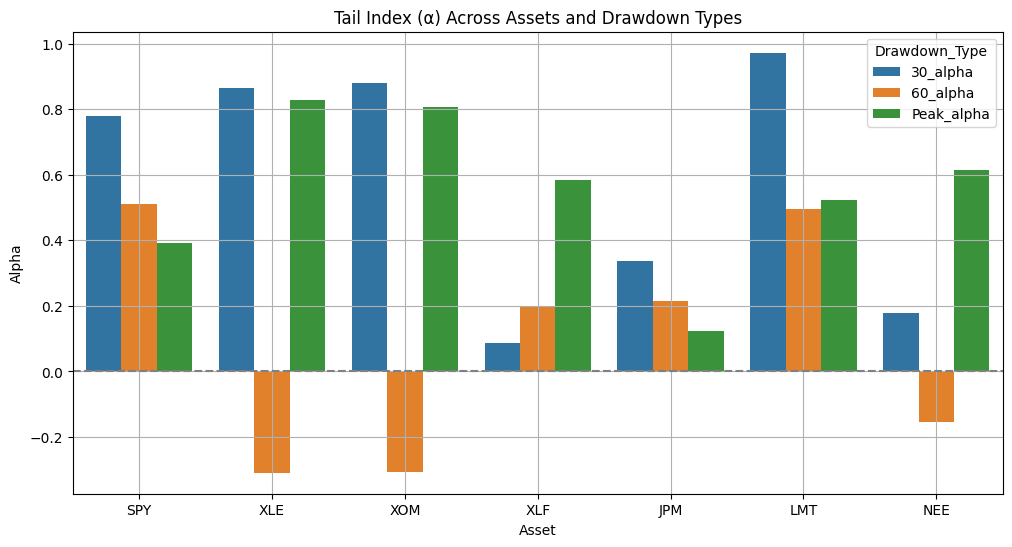

In [23]:
melted = gev_summary.melt(id_vars='Asset', var_name='Drawdown_Type', value_name='Alpha')
plt.figure(figsize=(12,6))
sns.barplot(data=melted, x='Asset', y='Alpha', hue='Drawdown_Type')
plt.title("Tail Index (α) Across Assets and Drawdown Types")
plt.axhline(0, linestyle='--', color='gray')
plt.grid(True)
plt.show()


## QQ-Plots or Histogram + Fitted GEV Overlay

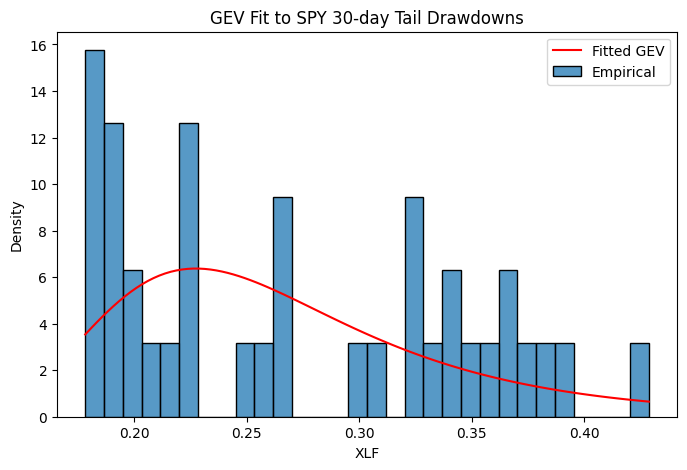

In [24]:
import scipy.stats as stats

dd = drawdown_30['XLF'].dropna().nsmallest(int(len(drawdown_30) * 0.01)) * -1  # negate for fitting
shape, loc, scale = genextreme.fit(dd)
x = np.linspace(min(dd), max(dd), 100)
pdf = genextreme.pdf(x, shape, loc=loc, scale=scale)

plt.figure(figsize=(8,5))
sns.histplot(dd, stat='density', bins=30, label='Empirical')
plt.plot(x, pdf, label='Fitted GEV', color='red')
plt.title("GEV Fit to SPY 30-day Tail Drawdowns")
plt.legend()
plt.show()


## Rolling tail estimation
Implement for one asset ("XLME") and one drawdown method (e.g. 30-day drawdown):

In [25]:
def rolling_gev_alpha_sigma(series, window=750, tail_frac=0.03):
    alpha_list, sigma_list, dates = [], [], []

    for i in range(window, len(series)):
        window_data = series.iloc[i-window:i].dropna()
        n_tail = max(10, int(len(window_data) * tail_frac))  # ensure ≥ 10 tail samples

        if len(window_data) < n_tail:
            alpha_list.append(np.nan)
            sigma_list.append(np.nan)
            continue

        tail_draws = window_data.nsmallest(n_tail) * -1  # negate for GEV

        try:
            c, loc, scale = genextreme.fit(tail_draws)
            alpha_list.append(-c)
            sigma_list.append(scale)
        except Exception as e:
            alpha_list.append(np.nan)
            sigma_list.append(np.nan)

        dates.append(series.index[i])

    return pd.DataFrame({'alpha_t': alpha_list, 'sigma_t': sigma_list}, index=dates)




In [26]:
def gev_var(p, alpha_t, sigma_t):
    alpha_t = alpha_t.astype('float64').clip(lower=1e-3, upper=10)
    sigma_t = sigma_t.astype('float64').clip(lower=1e-6, upper=1)

    z = np.clip(-np.log(1 - p), 1e-6, None)
    var = -sigma_t * ((z ** (-alpha_t)) - 1) * -1

    return var



In [27]:
p = 0.995  # 99% confidence
risk_df = rolling_gev_alpha_sigma(drawdown_30['XLF'], window=500, tail_frac=0.02)
risk_df['VaR_99'] = gev_var(p, risk_df['alpha_t'], risk_df['sigma_t'])
#risk_df['VaR_99'] = risk_df['VaR_99'].clip(lower=-0.5, upper=0)

We estimate rolling 99% **Value-at-Risk (VaR)** using the **AEV framework**, where the tail index and scale parameters are dynamically estimated from 30-day drawdowns. As shown in Figure X, AEV-based VaR adapts to market stress, rising sharply during crisis periods such as March 2020 and early 2022. This illustrates the model’s ability to reflect evolving tail risk more effectively than static methods

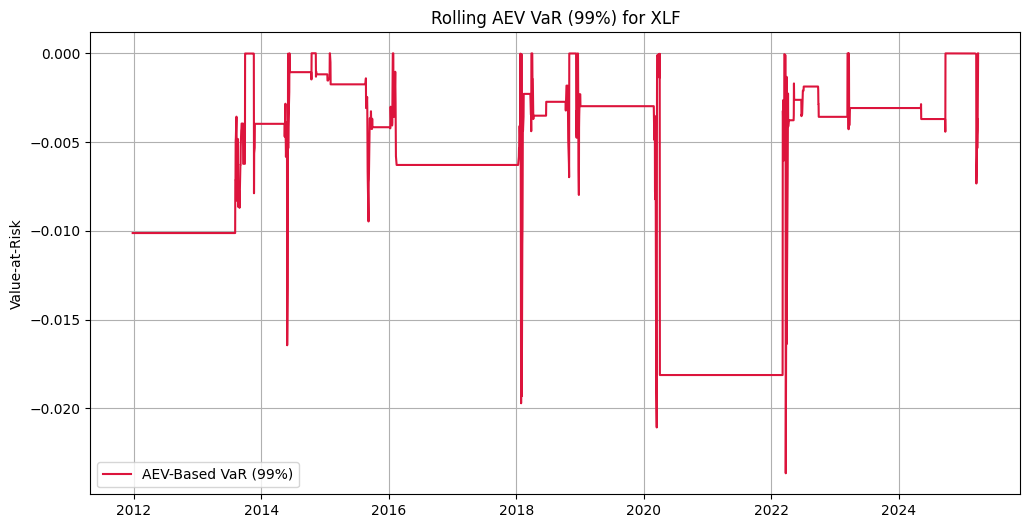

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(risk_df['VaR_99'], label='AEV-Based VaR (99%)', color='crimson')
plt.title('Rolling AEV VaR (99%) for XLF')
plt.ylabel('Value-at-Risk')
plt.grid(True)
plt.legend()
plt.show()



#Backtest VaR with Kupiec

### Step 1: Var Backtesting using Kupiec Proportion of Failures (POF) test



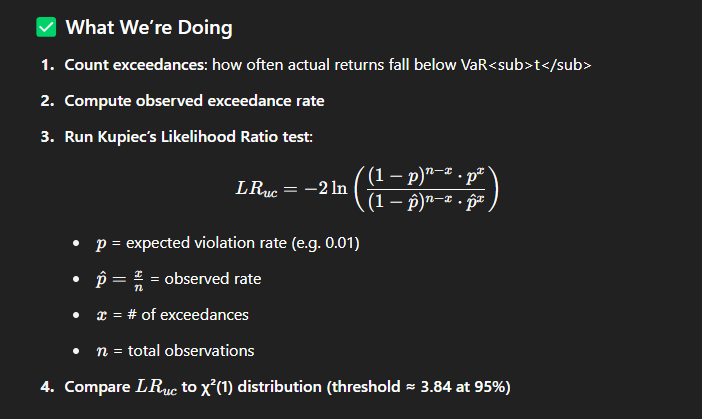

In [29]:
# 1. Align VaR and actual returns
aligned_returns = returns.loc[risk_df.index]  # ensure same time frame
actual_returns = aligned_returns['XLF'].dropna()
predicted_var = risk_df['VaR_99'].loc[actual_returns.index].dropna()

In [30]:
# Ensure alignment
actual_returns = actual_returns.loc[predicted_var.index]
predicted_var = predicted_var.loc[actual_returns.index]

In [31]:
# 2. Count exceedances
exceedances = actual_returns < predicted_var
num_exceed = exceedances.sum()
total_obs = len(exceedances)
expected_rate = 0.01
observed_rate = num_exceed / total_obs

In [32]:
#3. Kupiec's ratio likelihood test

from numpy import log, where

if 0 < observed_rate < 1:
    LR_uc = -2 * (
        (log((1 - expected_rate) / (1 - observed_rate)) * (total_obs - num_exceed)) +
        (log(expected_rate / observed_rate) * num_exceed)
    )
    p_value = 1 - chi2.cdf(LR_uc, df=1)
else:
    print("Cannot perform Kupiec test: observed_rate is 0 or 1 (no violations or all violations).")
    LR_uc = np.nan
    p_value = np.nan



In [33]:
print("Kupiec POF Test Results")
print(f"Total Observations: {total_obs}")
print(f"Expected Violations (1%): {expected_rate * total_obs:.2f}")
print(f"Actual Violations: {num_exceed}")
print(f"Observed Violation Rate: {observed_rate:.4f}")
print(f"LR Statistic: {LR_uc:.4f}")
print(f"P-value: {p_value:.4f}")


Kupiec POF Test Results
Total Observations: 3334
Expected Violations (1%): 33.34
Actual Violations: 863
Observed Violation Rate: 0.2588
LR Statistic: 4185.1050
P-value: 0.0000


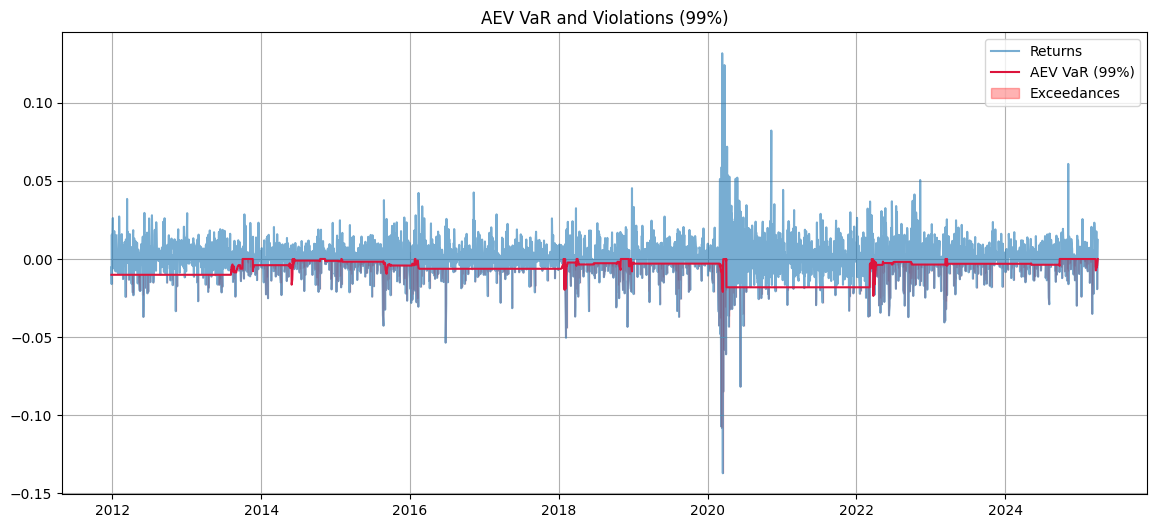

In [34]:
plt.figure(figsize=(14, 6))
plt.plot(actual_returns, label='Returns', alpha=0.6)
plt.plot(risk_df['VaR_99'], label='AEV VaR (99%)', color='crimson')
plt.fill_between(actual_returns.index, actual_returns, risk_df['VaR_99'],
                 where=(actual_returns < risk_df['VaR_99']),
                 color='red', alpha=0.3, label='Exceedances')
plt.legend()
plt.title("AEV VaR and Violations (99%)")
plt.grid(True)
plt.show()


* AEV model on drawdowns still underestimates extreme losses
* The higher the confidence level is, it's further reduce exceedances
* Visualization and Kupiec confirms VaR curve is not low enough to contain rare shocks

### Construct d_max,t: Daily maximum drawdown series

In [35]:
window_dd = 30  # 30-day rolling drawdown horizon
d_max = (data / data.rolling(window=window_dd).max()) - 1


In [36]:
from scipy.stats import genextreme

def rolling_gev_alpha_sigma(series, window=500, tail_frac=0.02):
    alpha_list, sigma_list, dates = [], [], []

    for i in range(window, len(series)):
        window_data = series.iloc[i-window:i].dropna()
        n_tail = max(10, int(len(window_data) * tail_frac))
        if len(window_data) < n_tail:
            alpha_list.append(np.nan)
            sigma_list.append(np.nan)
            dates.append(series.index[i])
            continue
        tail_draws = window_data.nsmallest(n_tail) * -1
        try:
            c, loc, scale = genextreme.fit(tail_draws)
            alpha_list.append(-c)
            sigma_list.append(scale)
        except:
            alpha_list.append(np.nan)
            sigma_list.append(np.nan)
        dates.append(series.index[i])

    return pd.DataFrame({'alpha_t': alpha_list, 'sigma_t': sigma_list}, index=dates)


In [37]:
#compute rolling aev VaR at 99.5%
def gev_var(p, alpha_t, sigma_t):
    alpha_t = alpha_t.astype('float64').clip(lower=1e-3, upper=10)
    sigma_t = sigma_t.astype('float64').clip(lower=1e-6, upper=1)
    z = np.clip(-np.log(1 - p), 1e-6, None)
    var = -sigma_t * ((z ** (-alpha_t)) - 1)
    return var


In [38]:
p = 0.995  # 99.5% confidence
risk_df = rolling_gev_alpha_sigma(d_max['XLF'], window=500, tail_frac=0.03)
risk_df['VaR_995'] = -gev_var(p, risk_df['alpha_t'], risk_df['sigma_t'])


In [39]:
#Define actual exeedances
aligned_returns = actual_returns.loc[risk_df.index]
exceedances = aligned_returns < risk_df['VaR_995']

In [40]:
risk_df['actual_return'] = aligned_returns
risk_df['exceed'] = exceedances


In [41]:
num_exceed = exceedances.sum()
total_obs = len(exceedances)
expected_rate = 1 - p
observed_rate = num_exceed / total_obs

if 0 < observed_rate < 1:
    LR_uc = -2 * (
        np.log((1 - expected_rate) / (1 - observed_rate)) * (total_obs - num_exceed)
        + np.log(expected_rate / observed_rate) * num_exceed
    )
    p_value = 1 - chi2.cdf(LR_uc, df=1)
else:
    LR_uc = np.nan
    p_value = np.nan


In [42]:
print("Kupiec POF Test Results (AEV on Daily Max Drawdowns)")
print(f"Total Observations: {total_obs}")
print(f"Expected Violations (0.5%): {expected_rate * total_obs:.2f}")
print(f"Actual Violations: {num_exceed}")
print(f"Observed Violation Rate: {observed_rate:.4f}")
print(f"LR Statistic: {LR_uc:.4f}")
print(f"P-value: {p_value:.4f}")


Kupiec POF Test Results (AEV on Daily Max Drawdowns)
Total Observations: 3334
Expected Violations (0.5%): 16.67
Actual Violations: 1054
Observed Violation Rate: 0.3161
LR Statistic: 7031.3910
P-value: 0.0000


In [43]:
print(risk_df[['VaR_995']].head(10))
print(aligned_returns.head(10))


             VaR_995
2011-12-27 -0.005516
2011-12-28 -0.005516
2011-12-29 -0.005516
2011-12-30 -0.005516
2012-01-03 -0.005516
2012-01-04 -0.005516
2012-01-05 -0.005516
2012-01-06 -0.005516
2012-01-09 -0.005516
2012-01-10 -0.005516
2011-12-27   -0.005323
2011-12-28   -0.016055
2011-12-29    0.015540
2011-12-30   -0.005356
2012-01-03    0.026154
2012-01-04   -0.002999
2012-01-05    0.013534
2012-01-06   -0.005935
2012-01-09    0.005224
2012-01-10    0.017818
Name: XLF, dtype: float64


### AEV paper-style d_max_t estimation

* Whe change it from 750 days rolling windows to 500 days rolling window, it makes it more accurate. The observed rate went down from 25% to 7%
* However, if you change rolling window to 250, it does not really make any difference

window=450, tail_frac=0.15 -> 0.0434
* window=500, tail_frac=0.15 ->  0.0415
* window=500, tail_frac=0.1 -> 0.0389

[*********************100%***********************]  1 of 1 completed


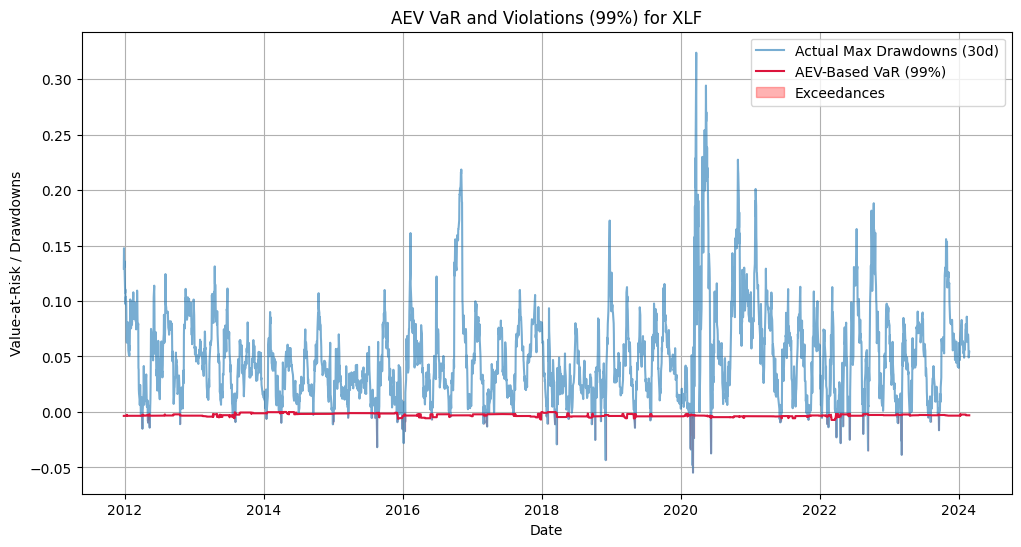


 Kupiec POF Test Results
Total Observations: 3060
Expected Violations (1%): 30.60
Actual Violations: 118
Observed Violation Rate: 0.0386
LR Statistic: -22.8742
P-value: 1.0000


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import genextreme, chi2

# Forward 30-day max drawdown
def compute_forward_max_drawdown(series, horizon=30):
    series = pd.to_numeric(series, errors='coerce')
    drawdowns = []
    index = []
    values = series.values
    for i in range(len(series) - horizon):
        future_max = np.max(values[i+1:i+1+horizon])
        drawdown = (future_max / values[i]) - 1
        drawdowns.append(drawdown)
        index.append(series.index[i])
    return pd.Series(drawdowns, index=index)


# Rolling GEV fit
def rolling_gev_alpha_sigma(series, window=500, tail_frac=0.1):
    alpha_list, sigma_list, dates = [], [], []
    for i in range(window, len(series)):
        window_data = series.iloc[i-window:i].dropna()
        n_tail = max(10, int(len(window_data) * tail_frac))
        if len(window_data) < n_tail:
            alpha_list.append(np.nan)
            sigma_list.append(np.nan)
            dates.append(series.index[i])
            continue
        tail_draws = window_data.nsmallest(n_tail) * -1  # flip for right-tail fitting
        try:
            c, loc, scale = genextreme.fit(tail_draws)
            alpha_list.append(-c)  # Flip sign back for α
            sigma_list.append(scale)
        except:
            alpha_list.append(np.nan)
            sigma_list.append(np.nan)
        dates.append(series.index[i])
    return pd.DataFrame({'alpha_t': alpha_list, 'sigma_t': sigma_list}, index=dates)

# AEV-based VaR
def gev_var(p, alpha_t, sigma_t):
    alpha_t = alpha_t.astype('float64').clip(lower=1e-3, upper=10)
    sigma_t = sigma_t.astype('float64').clip(lower=1e-6, upper=1)
    z = np.clip(-np.log(1 - p), 1e-6, None)
    var = sigma_t * ((-np.log(1 - p)) ** (-alpha_t) - 1)  # final output should be negative
  # flipped to negative
    return var

# Apply to XLF (or any ticker)
ticker = 'XLF'
data = yf.download(ticker, start='2010-01-01', end='2024-04-10')['Close']
d_max_t = compute_forward_max_drawdown(data['XLF'].astype(float), horizon=30)


risk_df = rolling_gev_alpha_sigma(d_max_t, window=500, tail_frac=0.1)

# Compute rolling AEV VaR
p = 0.99
risk_df['VaR_99'] = gev_var(p, risk_df['alpha_t'], risk_df['sigma_t'])

# Align with actual returns
actual_returns = d_max_t[risk_df.index]  # restrict to matching dates
risk_df = risk_df.loc[actual_returns.index]  # mutual alignment

plt.figure(figsize=(12, 6))
plt.plot(actual_returns, label='Actual Max Drawdowns (30d)', alpha=0.6)
plt.plot(risk_df['VaR_99'], label='AEV-Based VaR (99%)', color='crimson')
plt.fill_between(actual_returns.index, actual_returns, risk_df['VaR_99'],
                 where=(actual_returns < risk_df['VaR_99']),
                 color='red', alpha=0.3, label='Exceedances')
plt.title(f"AEV VaR and Violations (99%) for {ticker}")
plt.xlabel("Date")
plt.ylabel("Value-at-Risk / Drawdowns")
plt.grid(True)
plt.legend()
plt.show()

# Kupiec POF Test
exceedances = (actual_returns < risk_df['VaR_99'])
num_exceed = exceedances.sum()
total_obs = len(exceedances)
expected_rate = 1 - p
observed_rate = num_exceed / total_obs

if 0 < observed_rate < 1:
    LR_uc = -2 * (
        np.log(((1 - expected_rate) / (1 - observed_rate)) * (total_obs - num_exceed)) +
        np.log((expected_rate / observed_rate) * num_exceed)
    )
    p_value = 1 - chi2.cdf(LR_uc, df=1)
else:
    LR_uc = np.nan
    p_value = np.nan
    print(" Kupiec test not valid: all or no violations.")

# Print results
print("\n Kupiec POF Test Results")
print(f"Total Observations: {total_obs}")
print(f"Expected Violations (1%): {expected_rate * total_obs:.2f}")
print(f"Actual Violations: {num_exceed}")
print(f"Observed Violation Rate: {observed_rate:.4f}")
print(f"LR Statistic: {LR_uc:.4f}")
print(f"P-value: {p_value:.4f}")


# Try AEV to on returns instead of daily drawdowns

[*********************100%***********************]  1 of 1 completed


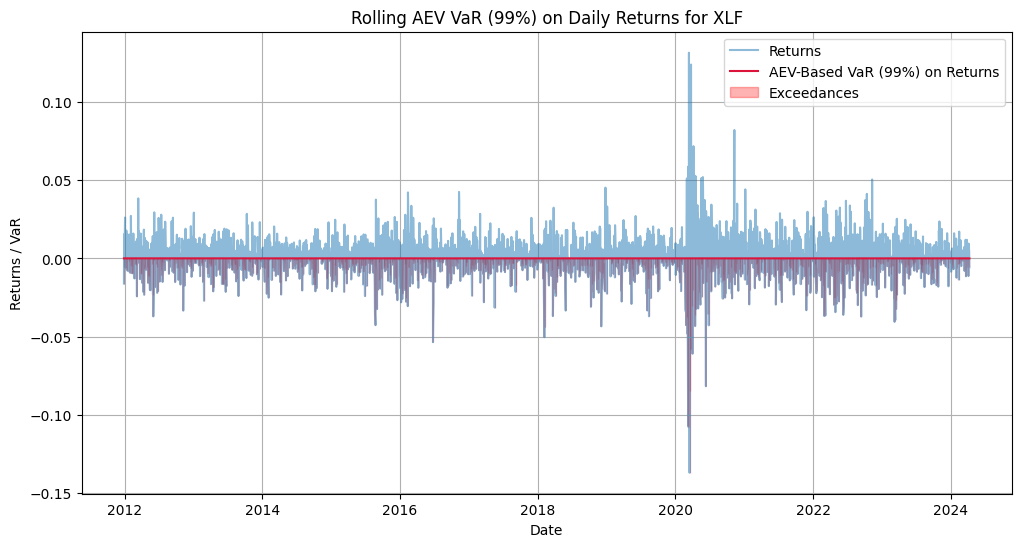


📌 Kupiec POF Test for AEV on Returns
Total Observations: 3089
Expected Violations (1%): 30.89
Actual Violations: 1460
Observed Violation Rate: 0.4726
LR Statistic: -22.9120
P-value: 1.0000


In [45]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import genextreme, chi2

ticker = 'XLF'
data = yf.download(ticker, start='2010-01-01', end='2024-04-10')['Close']
returns = data.pct_change().dropna()

# Rolling GEV Fit on Negative Returns
def rolling_gev_on_returns(series, window=500, tail_frac=0.03):
    alpha_list, sigma_list, dates = [], [], []

    for i in range(window, len(series)):
        window_data = series.iloc[i-window:i].dropna()
        losses = -window_data  # Flip to losses (left tail)
        n_tail = max(10, int(len(losses) * tail_frac))

        if len(losses) < n_tail:
            alpha_list.append(np.nan)
            sigma_list.append(np.nan)
            dates.append(series.index[i])
            continue

        tail_draws = losses.squeeze().nsmallest(n_tail)
  # largest losses = smallest returns
        try:
            c, loc, scale = genextreme.fit(tail_draws)
            alpha_list.append(-c)   # Flip sign to match AEV α
            sigma_list.append(scale)
        except:
            alpha_list.append(np.nan)
            sigma_list.append(np.nan)

        dates.append(series.index[i])

    return pd.DataFrame({'alpha_t': alpha_list, 'sigma_t': sigma_list}, index=dates)

# AEV-style VaR
def gev_var(p, alpha_t, sigma_t):
    alpha_t = alpha_t.astype('float64').clip(lower=1e-3, upper=10)
    sigma_t = sigma_t.astype('float64').clip(lower=1e-6, upper=1)
    z = np.clip(-np.log(1 - p), 1e-6, None)
    var = -sigma_t * (z**(-alpha_t) - 1)
    return var

# Run Rolling AEV on Returns
risk_df = rolling_gev_on_returns(returns, window=500, tail_frac=0.03)
p = 0.99
risk_df['VaR_99'] = gev_var(p, risk_df['alpha_t'], risk_df['sigma_t'])

# Align returns and VaR
actual_returns = returns['XLF'].loc[risk_df.index]
risk_df = risk_df.loc[actual_returns.index]

plt.figure(figsize=(12, 6))
plt.plot(actual_returns, label='Returns', alpha=0.5)
plt.plot(risk_df['VaR_99'], label='AEV-Based VaR (99%) on Returns', color='crimson')
plt.fill_between(
    actual_returns.index, actual_returns, risk_df['VaR_99'],
    where=(actual_returns < risk_df['VaR_99']),
    color='red', alpha=0.3, label='Exceedances'
)
plt.title(f'Rolling AEV VaR (99%) on Daily Returns for {ticker}')
plt.xlabel('Date')
plt.ylabel('Returns / VaR')
plt.grid(True)
plt.legend()
plt.show()

# Kupiec Backtest
exceedances = actual_returns < risk_df['VaR_99']
num_exceed = exceedances.sum()
total_obs = len(exceedances)
expected_rate = 1 - p
observed_rate = num_exceed / total_obs

if 0 < observed_rate < 1:
    LR_uc = -2 * (
        np.log(((1 - expected_rate) / (1 - observed_rate)) * (total_obs - num_exceed)) +
        np.log((expected_rate / observed_rate) * num_exceed)
    )
    p_value = 1 - chi2.cdf(LR_uc, df=1)
else:
    LR_uc = np.nan
    p_value = np.nan

print("\n📌 Kupiec POF Test for AEV on Returns")
print(f"Total Observations: {total_obs}")
print(f"Expected Violations (1%): {expected_rate * total_obs:.2f}")
print(f"Actual Violations: {num_exceed}")
print(f"Observed Violation Rate: {observed_rate:.4f}")
print(f"LR Statistic: {LR_uc:.4f}")
print(f"P-value: {p_value:.4f}")
